In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

import omegaconf
import dataclasses

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
ENV_NAME = 'cheetah' # cheetah | walker

In [3]:
BENCHMARK_SET = [0, 1, 2, 3]

NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

KEEP_ONLY_COORDS = False

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
from dm_control import suite

if ENV_NAME == 'cheetah':
    STATE_DIM = 17
    ACTION_DIM = 6
    # AUX_DIM = 1
    env = suite.load(
        domain_name='cheetah',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/cheetah_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_cheetah.npy')
    angmomentum_aux = np.load('datasets/angmomentum_aux_cheetah.npy')
    aux = np.concatenate((
        aux.reshape(10000, 1000, 1),
        angmomentum_aux.reshape(10000, 1000, 1)
    ), axis=-1)
    # dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 1)), axis=-1)
    
else:
    STATE_DIM = 24
    ACTION_DIM = 6
    # AUX_DIM = 3
    env = suite.load(
        domain_name='walker',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_walker.npy')
    angmomentum_aux = np.load('datasets/angmomentum_aux_walker.npy')
    aux = np.concatenate((
        aux.reshape(10000, 1000, 3),
        angmomentum_aux.reshape(10000, 1000, 1)
    ), axis=-1)
    # dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 3)), axis=-1)

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


In [5]:
dataset_trajectories = torch.tensor(dataset['observations']).float()
dataset_trajectories = dataset_trajectories
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions']).float()
dataset_terminals = torch.tensor(dataset['terminals']).float()
dataset_timeouts = torch.zeros(NUM_TRAJECTORIES, TRAJECTORY_LEN).bool()
dataset_timeouts[:, -1] = True

dataset_goals = torch.tensor(dataset['infos/goal']).float()



dataset_trajectories = dataset_trajectories.reshape(-1, TRAJECTORY_LEN, STATE_DIM)
dataset_actions = dataset_actions.reshape(-1, TRAJECTORY_LEN, ACTION_DIM)
dataset_terminals = dataset_terminals
dataset_timeouts = dataset_timeouts.reshape(-1, TRAJECTORY_LEN)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_):
    return dataset_

def denormalize_dataset_coords(dataset_):
    return dataset_

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [7]:
class VelocityRewardFunctionCheetah:
    def __init__(self):
        pass    
    
    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
        else:
            raise NotImplementedError
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='linear', value_at_margin=0):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return value
    
    def compute_reward(self, states, params):
        
        if params != 'flip':
            if isinstance(params, int):
                params = torch.full((*states.shape[:-1], 1), fill_value=params)
            
            assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

            horizontal_velocity = states[..., [0]]
            sign_of_param = np.sign(params)
            horizontal_velocity = horizontal_velocity * sign_of_param
            rew = self.tolerance(horizontal_velocity,
                                lower=np.abs(params),
                                upper=float('inf'),
                                margin=np.abs(params),
                                value_at_margin=0,
                                sigmoid='linear')
            
        else: # Flip
            _SPIN_SPEED = 5
            angmomentum = states[..., [1]]
            rew = self.tolerance(angmomentum,
                                lower=_SPIN_SPEED,
                                upper=float('inf'),
                                margin=_SPIN_SPEED,
                                value_at_margin=0,
                                sigmoid='linear')

        return torch.tensor(rew[..., 0], dtype=torch.float32)
    
    
    

class VelocityRewardFunctionWalker:
    def __init__(self):
        pass    

    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'gaussian':
            scale = np.sqrt(-2 * np.log(value_at_1))
            return np.exp(-0.5 * (x*scale)**2)

        elif sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='gaussian', value_at_margin=0.1):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return torch.tensor(value)
    
    def compute_reward(self, states, params):
        
        if params != 'flip':
            if isinstance(params, int) or isinstance(params, float):
                params = torch.full((*states.shape[:-1], 1), fill_value=params)
            
            assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

            _STAND_HEIGHT = 1.2
            horizontal_velocity = states[..., [0]]
            torso_upright = states[..., [1]]
            torso_height = states[..., [2]]
            standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
            upright = (1 + torso_upright) / 2
            stand_reward = (3*standing + upright) / 4
            move_reward = self.tolerance(horizontal_velocity,
                                            lower=params,
                                            upper=float('inf'),
                                            margin=params/2,
                                            value_at_margin=0.5,
                                            sigmoid='linear')
            # move_reward[params == 0] = stand_reward[params == 0]
            
        
        else: # flip
            _STAND_HEIGHT = 1.2
            _SPIN_SPEED = 5
            horizontal_velocity = states[..., [0]]
            torso_upright = states[..., [1]]
            torso_height = states[..., [2]]
            angmomentum = states[..., [3]]
            standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
            upright = (1 + torso_upright) / 2
            stand_reward = (3*standing + upright) / 4
            move_reward = self.tolerance(angmomentum,
                                            lower=_SPIN_SPEED,
                                            upper=float('inf'),
                                            margin=_SPIN_SPEED,
                                            value_at_margin=0.5,
                                            sigmoid='linear')
            # move_reward[params == 0] = stand_reward[params == 0]
        
        rew = stand_reward * (5*move_reward + 1) / 6    
                
        return torch.tensor(rew[..., 0], dtype=torch.float32)
    
    
    
    
if ENV_NAME == 'cheetah':
    velocity_reward_function = VelocityRewardFunctionCheetah()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel10Back', -10),
        (velocity_reward_function.compute_reward, 'vel2Back', -2),
        (velocity_reward_function.compute_reward, 'vel2', 2),
        (velocity_reward_function.compute_reward, 'vel10', 10),
        (velocity_reward_function.compute_reward, 'flip', 'flip'),
    ]
else:
    velocity_reward_function = VelocityRewardFunctionWalker()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel0.1', 0.1),
        (velocity_reward_function.compute_reward, 'vel1', 1),
        (velocity_reward_function.compute_reward, 'vel4', 4),
        (velocity_reward_function.compute_reward, 'vel8', 8),
        (velocity_reward_function.compute_reward, 'flip', 'flip'),
    ]

In [8]:
@dataclasses.dataclass
class Dataset:
    trajectories: torch.Tensor
    actions: torch.Tensor
    terminals: torch.Tensor
    timeouts: torch.Tensor

dataset = Dataset(
        trajectories=dataset_trajectories,
        actions=dataset_actions,
        terminals=dataset_terminals,
        timeouts=dataset_timeouts
    )


def get_iql_training_data(dataset:Dataset, batch_size):

    num_trajectories, len_trajectory, obs_dim = dataset.trajectories.shape

    trajectory_idx = torch.randint(0, num_trajectories, (batch_size,))
    state_idx = torch.randint(0, len_trajectory, (batch_size,)) % (len_trajectory - 1)

    states = dataset.trajectories[trajectory_idx, state_idx].reshape(batch_size, obs_dim)
    next_states = dataset.trajectories[trajectory_idx, state_idx+1].reshape(batch_size, obs_dim)
    actions = dataset.actions[trajectory_idx, state_idx].reshape(batch_size, -1)
    
    aux_ = aux[trajectory_idx, state_idx].reshape(batch_size, -1)
    aux_ = torch.tensor(aux_)
    
    # return {
    #     'states': states.to(device),
    #     'actions': actions.to(device),
    #     'next_states': next_states.to(device),
    # }
    
    return (
        states.to(device), actions.to(device), next_states.to(device), aux_
    )

In [9]:
import typing as tp
import math


def _nl(name: str, dim: int) -> tp.List[nn.Module]:
    """Returns a non-linearity given name and dimension"""
    if name == "irelu":
        return [nn.ReLU(inplace=True)]
    if name == "relu":
        return [nn.ReLU()]
    if name == "ntanh":
        return [nn.LayerNorm(dim), nn.Tanh()]
    if name == "layernorm":
        return [nn.LayerNorm(dim)]
    if name == "tanh":
        return [nn.Tanh()]
    if name == "L2":
        return [_L2(dim)]
    raise ValueError(f"Unknown non-linearity {name}")


def mlp(*layers: tp.Sequence[tp.Union[int, str]]) -> nn.Sequential:
    """Provides a sequence of linear layers and non-linearities
    providing a sequence of dimension for the neurons, or name of
    the non-linearities
    Eg: mlp(10, 12, "relu", 15) returns:
    Sequential(Linear(10, 12), ReLU(), Linear(12, 15))
    """
    assert len(layers) >= 2
    sequence: tp.List[nn.Module] = []
    assert isinstance(layers[0], int), "First input must provide the dimension"
    prev_dim: int = layers[0]
    for layer in layers[1:]:
        if isinstance(layer, str):
            sequence.extend(_nl(layer, prev_dim))
        else:
            assert isinstance(layer, int)
            sequence.append(nn.Linear(prev_dim, layer))
            prev_dim = layer
    return nn.Sequential(*sequence)




class ForwardMap(nn.Module):
    """ forward representation class"""

    def __init__(self, obs_dim, z_dim, action_dim, feature_dim, hidden_dim,
                 preprocess=False, add_trunk=True) -> None:
        super().__init__()
        self.obs_dim = obs_dim
        self.z_dim = z_dim
        self.action_dim = action_dim
        self.preprocess = preprocess

        if self.preprocess:
            self.obs_action_net = mlp(self.obs_dim + self.action_dim, hidden_dim, "ntanh", feature_dim, "irelu")
            self.obs_z_net = mlp(self.obs_dim + self.z_dim, hidden_dim, "ntanh", feature_dim, "irelu")
            if not add_trunk:
                self.trunk: nn.Module = nn.Identity()
                feature_dim = 2 * feature_dim
            else:
                self.trunk = mlp(2 * feature_dim, hidden_dim, "irelu")
                feature_dim = hidden_dim
        else:
            self.trunk = mlp(self.obs_dim + self.z_dim + self.action_dim, hidden_dim, "ntanh",
                             hidden_dim, "irelu",
                             hidden_dim, "irelu")
            feature_dim = hidden_dim

        seq = [feature_dim, hidden_dim, "irelu", self.z_dim]
        self.F1 = mlp(*seq)
        self.F2 = mlp(*seq)


    def forward(self, obs, z, action):
        assert z.shape[-1] == self.z_dim

        if self.preprocess:
            obs_action = self.obs_action_net(torch.cat([obs, action], dim=-1))
            obs_z = self.obs_z_net(torch.cat([obs, z], dim=-1))
            h = torch.cat([obs_action, obs_z], dim=-1)
        else:
            h = torch.cat([obs, z, action], dim=-1)
        if hasattr(self, "trunk"):
            h = self.trunk(h)
        F1 = self.F1(h)
        F2 = self.F2(h)
        return F1, F2



class BackwardMap(nn.Module):
    """ backward representation class"""

    def __init__(self, obs_dim, z_dim, hidden_dim, norm_z: bool = True) -> None:
        super().__init__()
        self.obs_dim = obs_dim
        self.z_dim = z_dim
        self.norm_z = norm_z

        self.B = mlp(self.obs_dim, hidden_dim, "ntanh", hidden_dim, "relu", self.z_dim)

    def forward(self, obs):
        if not hasattr(self, "norm_z"):  # backward compatiblity
            self.norm_z = True

        B = self.B(obs)
        if self.norm_z:
            B = math.sqrt(self.z_dim) * F.normalize(B, dim=1)
        return B




class Actor(nn.Module):
    def __init__(self, obs_dim, z_dim, action_dim, feature_dim, hidden_dim,
                 preprocess=False, add_trunk=True) -> None:
        super().__init__()
        self.obs_dim = obs_dim
        self.z_dim = z_dim
        self.action_dim = action_dim
        self.preprocess = preprocess

        if self.preprocess:
            self.obs_net = mlp(self.obs_dim, hidden_dim, "ntanh", feature_dim, "irelu")
            self.obs_z_net = mlp(self.obs_dim + self.z_dim, hidden_dim, "ntanh", feature_dim, "irelu")
            if not add_trunk:
                self.trunk: nn.Module = nn.Identity()
                feature_dim = 2 * feature_dim
            else:
                self.trunk = mlp(2 * feature_dim, hidden_dim, "irelu")
                feature_dim = hidden_dim
        else:
            self.trunk = mlp(self.obs_dim + self.z_dim, hidden_dim, "ntanh",
                             hidden_dim, "irelu",
                             hidden_dim, "irelu")
            feature_dim = hidden_dim

        self.policy = mlp(feature_dim, hidden_dim, "irelu", self.action_dim)
        # self.apply(utils.weight_init)
        # initialize the last layer by zero
        # self.policy[-1].weight.data.fill_(0.0)

    def forward(self, obs, z, std):
        assert z.shape[-1] == self.z_dim

        if self.preprocess:
            obs_z = self.obs_z_net(torch.cat([obs, z], dim=-1))
            obs = self.obs_net(obs)
            h = torch.cat([obs, obs_z], dim=-1)
        else:
            h = torch.cat([obs, z], dim=-1)
        if hasattr(self, "trunk"):
            h = self.trunk(h)
        mu = self.policy(h)
        mu = torch.tanh(mu)
        std = torch.ones_like(mu) * std

        dist = TruncatedNormal(mu, std)
        return dist

In [10]:



@dataclasses.dataclass
class FBDDPGAgentConfig:
    # @package agent
    _target_: str = "url_benchmark.agent.fb_ddpg.FBDDPGAgent"
    name: str = "fb_ddpg"
    # reward_free: ${reward_free}
    obs_type: str = omegaconf.MISSING  # to be specified later
    obs_shape: tp.Tuple[int, ...] = omegaconf.MISSING  # to be specified later
    action_shape: tp.Tuple[int, ...] = omegaconf.MISSING  # to be specified later
    device: str = omegaconf.II("device")  # ${device}
    lr: float = 1e-4
    lr_coef: float = 1
    fb_target_tau: float = 0.01  # 0.001-0.01
    update_every_steps: int = 2
    use_tb: bool = omegaconf.II("use_tb")  # ${use_tb}
    use_wandb: bool = omegaconf.II("use_wandb")  # ${use_wandb}
    use_hiplog: bool = omegaconf.II("use_hiplog")  # ${use_wandb}
    num_expl_steps: int = omegaconf.MISSING  # ???  # to be specified later
    num_inference_steps: int = 5120
    hidden_dim: int = 1024   # 128, 2048
    backward_hidden_dim: int = 526   # 512
    feature_dim: int = 512   # 128, 1024
    z_dim: int = 50  # 100
    stddev_schedule: str = "0.2"  # "linear(1,0.2,200000)" #
    stddev_clip: float = 0.3  # 1
    update_z_every_step: int = 300
    update_z_proba: float = 1.0
    nstep: int = 1
    batch_size: int = 1024  # 512
    init_fb: bool = True
    update_encoder: bool = omegaconf.II("update_encoder")  # ${update_encoder}
    goal_space: tp.Optional[str] = omegaconf.II("goal_space")
    ortho_coef: float = 1.0  # 0.01-10
    log_std_bounds: tp.Tuple[float, float] = (-5, 2)  # param for DiagGaussianActor
    temp: float = 1  # temperature for DiagGaussianActor
    boltzmann: bool = False  # set to true for DiagGaussianActor
    debug: bool = False
    future_ratio: float = 0.0
    mix_ratio: float = 0.5  # 0-1
    rand_weight: bool = False  # True, False
    preprocess: bool = True
    norm_z: bool = True
    q_loss: bool = False
    q_loss_coef: float = 0.01
    additional_metric: bool = False
    add_trunk: bool = False


In [11]:

def soft_update_params(net, target_net, tau) -> None:
    for param, target_param in zip(net.parameters(), target_net.parameters()):
        target_param.data.copy_(tau * param.data +
                                (1 - tau) * target_param.data)
import re
def schedule(schdl, step) -> float:
    try:
        return float(schdl)
    except ValueError:
        match = re.match(r'linear\((.+),(.+),(.+)\)', schdl)
        if match:
            init, final, duration = [float(g) for g in match.groups()]
            mix = np.clip(step / duration, 0.0, 1.0)
            return (1.0 - mix) * init + mix * final
        match = re.match(r'step_linear\((.+),(.+),(.+),(.+),(.+)\)', schdl)
        if match:
            init, final1, duration1, final2, duration2 = [
                float(g) for g in match.groups()
            ]
            if step <= duration1:
                mix = np.clip(step / duration1, 0.0, 1.0)
                return (1.0 - mix) * init + mix * final1
            else:
                mix = np.clip((step - duration1) / duration2, 0.0, 1.0)
                return (1.0 - mix) * final1 + mix * final2
    raise NotImplementedError(schdl)

class TruncatedNormal(torch.distributions.Normal):
    def __init__(self, loc, scale, low=-1.0, high=1.0, eps=1e-6) -> None:
        super().__init__(loc, scale, validate_args=False)
        self.low = low
        self.high = high
        self.eps = eps

    def _clamp(self, x) -> torch.Tensor:
        clamped_x = torch.clamp(x, self.low + self.eps, self.high - self.eps)
        x = x - x.detach() + clamped_x.detach()
        return x

    def sample(self, clip=None, sample_shape=torch.Size()) -> torch.Tensor:  # type: ignore
        shape = self._extended_shape(sample_shape)
        eps = torch.distributions.utils._standard_normal(shape,
                               dtype=self.loc.dtype,
                               device=self.loc.device)
        eps *= self.scale
        if clip is not None:
            eps = torch.clamp(eps, -clip, clip)
        x = self.loc + eps
        return self._clamp(x)



class FBDDPGAgent(nn.Module):
    def __init__(self, **kwargs: tp.Any):
        super(FBDDPGAgent, self).__init__()
        
        cfg = FBDDPGAgentConfig(**kwargs)
        self.cfg = cfg
        
        self.obs_dim = 17
        self.action_dim = 6
        
        self.forward_net = ForwardMap(self.obs_dim, cfg.z_dim, self.action_dim,
            cfg.feature_dim, cfg.hidden_dim,
            preprocess=cfg.preprocess, add_trunk=self.cfg.add_trunk).to(device)
        
        self.forward_target_net = ForwardMap(self.obs_dim, cfg.z_dim, self.action_dim,
            cfg.feature_dim, cfg.hidden_dim,
            preprocess=cfg.preprocess, add_trunk=self.cfg.add_trunk).to(device)
        
        self.backward_net = BackwardMap(self.obs_dim, cfg.z_dim, cfg.backward_hidden_dim, norm_z=cfg.norm_z).to(device)
        self.backward_target_net = BackwardMap(self.obs_dim, cfg.z_dim, cfg.backward_hidden_dim, norm_z=cfg.norm_z).to(device)
        
        # load the weights into the target networks
        self.forward_target_net.load_state_dict(self.forward_net.state_dict())
        self.backward_target_net.load_state_dict(self.backward_net.state_dict())
        
        
        
        self.actor = Actor(self.obs_dim, cfg.z_dim, self.action_dim,
                               cfg.feature_dim, cfg.hidden_dim,
                               preprocess=cfg.preprocess, add_trunk=self.cfg.add_trunk).to(device)
        
        
        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=cfg.lr)

        self.fb_opt = torch.optim.Adam([{'params': self.forward_net.parameters()},  # type: ignore
                                        {'params': self.backward_net.parameters(), 'lr': cfg.lr_coef * cfg.lr}],
                                       lr=cfg.lr)
        
        self.train()
        self.forward_target_net.train()
        self.backward_target_net.train()
        
        self.device = device
    
    def train(self, training: bool = True) -> None:
        self.training = training
        for net in [self.actor, self.forward_net, self.backward_net]:
            net.train(training)
        
    def sample_z(self, size, device: str = "cpu"):
        gaussian_rdv = torch.randn((size, self.cfg.z_dim), dtype=torch.float32, device=device)
        gaussian_rdv = F.normalize(gaussian_rdv, dim=1)
        if self.cfg.norm_z:
            z = math.sqrt(self.cfg.z_dim) * gaussian_rdv
        else:
            uniform_rdv = torch.rand((size, self.cfg.z_dim), dtype=torch.float32, device=device)
            z = np.sqrt(self.cfg.z_dim) * uniform_rdv * gaussian_rdv
        return z
    
    
    
    
    def update_fb(
        self,
        obs: torch.Tensor,
        action: torch.Tensor,
        discount: torch.Tensor,
        next_obs: torch.Tensor,
        next_goal: torch.Tensor,
        z: torch.Tensor,
        step: int
    ) -> tp.Dict[str, float]:
        metrics: tp.Dict[str, float] = {}
        # compute target successor measure
        with torch.no_grad():
            if self.cfg.boltzmann:
                dist = self.actor(next_obs, z)
                next_action = dist.sample()
            else:
                stddev = schedule(self.cfg.stddev_schedule, step)
                dist = self.actor(next_obs, z, stddev)
                next_action = dist.sample(clip=self.cfg.stddev_clip)
            target_F1, target_F2 = self.forward_target_net(next_obs, z, next_action)  # batch x z_dim
            target_B = self.backward_target_net(next_goal)  # batch x z_dim
            target_M1 = torch.einsum('sd, td -> st', target_F1, target_B)  # batch x batch
            target_M2 = torch.einsum('sd, td -> st', target_F2, target_B)  # batch x batch
            target_M = torch.min(target_M1, target_M2)

        # compute FB loss
        F1, F2 = self.forward_net(obs, z, action)
        B = self.backward_net(next_goal)
        M1 = torch.einsum('sd, td -> st', F1, B)  # batch x batch
        M2 = torch.einsum('sd, td -> st', F2, B)  # batch x batch
        I = torch.eye(*M1.size(), device=M1.device)
        off_diag = ~I.bool()
        fb_offdiag: tp.Any = 0.5 * sum((M - discount * target_M)[off_diag].pow(2).mean() for M in [M1, M2])
        fb_diag: tp.Any = -sum(M.diag().mean() for M in [M1, M2])
        fb_loss = fb_offdiag + fb_diag

        # Q LOSS

        if self.cfg.q_loss:
            with torch.no_grad():
                next_Q1, nextQ2 = [torch.einsum('sd, sd -> s', target_Fi, z) for target_Fi in [target_F1, target_F2]]
                next_Q = torch.min(next_Q1, nextQ2)
                cov = torch.matmul(B.T, B) / B.shape[0]
                inv_cov = torch.inverse(cov)
                implicit_reward = (torch.matmul(B, inv_cov) * z).sum(dim=1)  # batch_size
                target_Q = implicit_reward.detach() + discount.squeeze(1) * next_Q  # batch_size
            Q1, Q2 = [torch.einsum('sd, sd -> s', Fi, z) for Fi in [F1, F2]]
            q_loss = F.mse_loss(Q1, target_Q) + F.mse_loss(Q2, target_Q)
            fb_loss += self.cfg.q_loss_coef * q_loss

        # ORTHONORMALITY LOSS 

        Cov = torch.matmul(B, B.T)
        orth_loss_diag = - 2 * Cov.diag().mean()
        orth_loss_offdiag = Cov[off_diag].pow(2).mean()
        orth_loss = orth_loss_offdiag + orth_loss_diag
        fb_loss += self.cfg.ortho_coef * orth_loss

        # Cov = torch.cov(B.T)  # Vicreg loss
        # var_loss = F.relu(1 - Cov.diag().clamp(1e-4, 1).sqrt()).mean()  # eps avoids inf. sqrt gradient at 0
        # cov_loss = 2 * torch.triu(Cov, diagonal=1).pow(2).mean() # 2x upper triangular part
        # orth_loss =  var_loss + cov_loss
        # fb_loss += self.cfg.ortho_coef * orth_loss

        if self.cfg.use_tb or self.cfg.use_wandb or self.cfg.use_hiplog:
            metrics['target_M'] = target_M.mean().item()
            metrics['M1'] = M1.mean().item()
            metrics['F1'] = F1.mean().item()
            metrics['B'] = B.mean().item()
            metrics['B_norm'] = torch.norm(B, dim=-1).mean().item()
            metrics['z_norm'] = torch.norm(z, dim=-1).mean().item()
            metrics['fb_loss'] = fb_loss.item()
            metrics['fb_diag'] = fb_diag.item()
            metrics['fb_offdiag'] = fb_offdiag.item()
            if self.cfg.q_loss:
                metrics['q_loss'] = q_loss.item()
            metrics['orth_loss'] = orth_loss.item()
            metrics['orth_loss_diag'] = orth_loss_diag.item()
            metrics['orth_loss_offdiag'] = orth_loss_offdiag.item()
            if self.cfg.q_loss:
                metrics['q_loss'] = q_loss.item()
            eye_diff = torch.matmul(B.T, B) / B.shape[0] - torch.eye(B.shape[1], device=B.device)
            metrics['orth_linf'] = torch.max(torch.abs(eye_diff)).item()
            metrics['orth_l2'] = eye_diff.norm().item() / math.sqrt(B.shape[1])
            if isinstance(self.fb_opt, torch.optim.Adam):
                metrics["fb_opt_lr"] = self.fb_opt.param_groups[0]["lr"]

        # optimize FB
        # if self.encoder_opt is not None:
            # self.encoder_opt.zero_grad(set_to_none=True)
        self.fb_opt.zero_grad(set_to_none=True)
        fb_loss.backward()
        self.fb_opt.step()
        # if self.encoder_opt is not None:
            # self.encoder_opt.step()
        return metrics

    def update_actor(self, obs: torch.Tensor, z: torch.Tensor, step: int) -> tp.Dict[str, float]:
        metrics: tp.Dict[str, float] = {}
        if self.cfg.boltzmann:
            dist = self.actor(obs, z)
            action = dist.rsample()
        else:
            stddev = schedule(self.cfg.stddev_schedule, step)
            dist = self.actor(obs, z, stddev)
            action = dist.sample(clip=self.cfg.stddev_clip)

        log_prob = dist.log_prob(action).sum(-1, keepdim=True)
        F1, F2 = self.forward_net(obs, z, action)
        Q1 = torch.einsum('sd, sd -> s', F1, z)
        Q2 = torch.einsum('sd, sd -> s', F2, z)
        if self.cfg.additional_metric:
            q1_success = Q1 > Q2
        Q = torch.min(Q1, Q2)
        actor_loss = (self.cfg.temp * log_prob - Q).mean() if self.cfg.boltzmann else -Q.mean()

        # optimize actor
        self.actor_opt.zero_grad(set_to_none=True)
        actor_loss.backward()
        self.actor_opt.step()

        if self.cfg.use_tb or self.cfg.use_wandb:
            metrics['actor_loss'] = actor_loss.item()
            metrics['q'] = Q.mean().item()
            if self.cfg.additional_metric:
                metrics['q1_success'] = q1_success.float().mean().item()
            metrics['actor_logprob'] = log_prob.mean().item()
            # metrics['actor_ent'] = dist.entropy().sum(dim=-1).mean().item()

        return metrics

    def get_implicit_reward(self, obs, z, expectation_nb=2048):
        
        with torch.no_grad():
            B_obs = self.backward_net(obs)

            expectation_obs, _, _, _ = get_iql_training_data(dataset, batch_size=expectation_nb)
            B = self.backward_net(expectation_obs)

            cov = torch.matmul(B.T, B) / B.shape[0]
            inv_cov = torch.inverse(cov)
            implicit_reward = (torch.matmul(B_obs, inv_cov) * z).sum(dim=1)
        
        return implicit_reward

    
    # def update(self, replay_loader, step: int) -> tp.Dict[str, float]:
    def update(self, obs, action, next_obs, step: int, discount=0.95) -> tp.Dict[str, float]:
        metrics: tp.Dict[str, float] = {}

        if step % self.cfg.update_every_steps != 0:
            return metrics

        z = self.sample_z(self.cfg.batch_size, device=self.device)
        if not z.shape[-1] == self.cfg.z_dim:
            raise RuntimeError("There's something wrong with the logic here")


        # perm = torch.randperm(self.cfg.batch_size)
        # backward_input = backward_input[perm]

        # if self.cfg.mix_ratio > 0:
        #     mix_idxs: tp.Any = np.where(np.random.uniform(size=self.cfg.batch_size) < self.cfg.mix_ratio)[0]
        #     if not self.cfg.rand_weight:
        #         with torch.no_grad():
        #             mix_z = self.backward_net(backward_input[mix_idxs]).detach()
        #     else:
        #         # generate random weight
        #         weight = torch.rand(size=(mix_idxs.shape[0], self.cfg.batch_size)).to(self.device)
        #         weight = F.normalize(weight, dim=1)
        #         uniform_rdv = torch.rand(mix_idxs.shape[0], 1).to(self.device)
        #         weight = uniform_rdv * weight
        #         with torch.no_grad():
        #             mix_z = torch.matmul(weight, self.backward_net(backward_input).detach())
        #     if self.cfg.norm_z:
        #         mix_z = math.sqrt(self.cfg.z_dim) * F.normalize(mix_z, dim=1)
        #     z[mix_idxs] = mix_z

        # hindsight replay
        # if self.cfg.future_ratio > 0:
            # assert future_goal is not None
            # future_idxs = np.where(np.random.uniform(size=self.cfg.batch_size) < self.cfg.future_ratio)
            # z[future_idxs] = self.backward_net(future_goal[future_idxs]).detach()

        metrics.update(self.update_fb(obs=obs, action=action, discount=discount,
                                      next_obs=next_obs, next_goal=next_obs, z=z, step=step))

        # update actor
        metrics.update(self.update_actor(obs, z, step))

        # update critic target
        soft_update_params(self.forward_net , self.forward_target_net , self.cfg.fb_target_tau)
        soft_update_params(self.backward_net, self.backward_target_net, self.cfg.fb_target_tau)

        # update inv cov
        # if step % self.cfg.update_cov_every_step == 0:
        #     logger.info("update online cov")
        #     obs_list = list()
        #     batch_size = 0
        #     while batch_size < 10000:
        #         batch = next(replay_loader)
        #         batch = batch.to(self.device)
        #         obs_list.append(batch.next_goal if self.cfg.goal_space is not None else batch.next_obs)
        #         batch_size += batch.next_obs.size(0)
        #     obs = torch.cat(obs_list, 0)
        #     with torch.no_grad():
        #         B = self.backward_net(obs)
        #     self.inv_cov = torch.inverse(self.online_cov(B))

        return metrics


    def infer_meta_from_obs_and_rewards(self, obs: torch.Tensor, reward: torch.Tensor):
        # print('max reward: ', reward.max().cpu().item())
        # print('99 percentile: ', torch.quantile(reward, 0.99).cpu().item())
        # print('median reward: ', reward.median().cpu().item())
        # print('min reward: ', reward.min().cpu().item())
        # print('mean reward: ', reward.mean().cpu().item())
        # print('num reward: ', reward.shape[0])

        # filter out small reward
        # pdb.set_trace()
        # idx = torch.where(reward >= torch.quantile(reward, 0.99))[0]
        # obs = obs[idx]
        # reward = reward[idx]
        with torch.no_grad():
            B = self.backward_net(obs)
        z = torch.matmul(reward.T, B) / reward.shape[0]
        if self.cfg.norm_z:
            # print(z)
            z = math.sqrt(self.cfg.z_dim) * F.normalize(z, dim=0)
        meta = dict()
        # meta['z'] = z.squeeze().cpu().numpy()
        meta['z'] = z.squeeze()
        # self.solved_meta = meta
        return meta

    
    def act(self, obs, meta, step, eval_mode) -> tp.Any:
        obs = torch.as_tensor(obs, device=self.device, dtype=torch.float32).unsqueeze(0)  # type: ignore
        z = torch.as_tensor(meta['z'], device=self.device).unsqueeze(0)  # type: ignore
        
        # print(obs.shape, z.shape)
        
        with torch.no_grad():
            if self.cfg.boltzmann:
                dist = self.actor(obs, z)
            else:
                stddev = schedule(self.cfg.stddev_schedule, step)
                dist = self.actor(obs, z, stddev)
        
        
        if eval_mode:
            action = dist.mean
            if self.cfg.additional_metric:
                # the following is doing extra computation only used for metrics,
                # it should be deactivated eventually
                F_mean_s = self.forward_net(obs, z, action)
                # F_samp_s = self.forward_net(obs, z, dist.sample())
                F_rand_s = self.forward_net(obs, z, torch.zeros_like(action).uniform_(-1.0, 1.0))
                Qs = [torch.min(*(torch.einsum('sd, sd -> s', F, z) for F in Fs)) for Fs in [F_mean_s, F_rand_s]]
                self.actor_success = (Qs[0] > Qs[1]).cpu().numpy().tolist()
        else:
            action = dist.sample()
            if step < self.cfg.num_expl_steps:
                action.uniform_(-1.0, 1.0)
                
        return action.cpu().numpy()[0]

In [12]:
# nb_eval_samples = 10000
# eval_obs, _, _, eval_aux = get_iql_training_data(dataset, batch_size=nb_eval_samples)
# benchmark_id = 3
# benchmark_reward_function, _, benchmark_param = benchmarks[benchmark_id]
# eval_reward = benchmark_reward_function(eval_aux, benchmark_param).to(device)

# meta = fb_agent.infer_meta_from_obs_and_rewards(eval_obs, eval_reward)

# fb_agent.act(eval_obs[0], meta, eval_mode=True, step=0)

In [13]:
# eval_obs, _, _, eval_aux = get_iql_training_data(dataset, batch_size=10_000)
# pred_reward = fb_agent.get_implicit_reward(eval_obs, meta['z'], expectation_nb=10_000).cpu()
# eval_reward = benchmark_reward_function(eval_aux, benchmark_param).cpu()

# fig, axs = plt.subplots(1, 2, figsize=(10, 4))
# axs[0].scatter(eval_obs[:, 8].cpu(), eval_obs[:, 0].cpu(), c=pred_reward)
# axs[1].scatter(eval_obs[:, 8].cpu(), eval_obs[:, 0].cpu(), c=eval_reward)

In [14]:
def timestep2obs(timestep):
    obs = np.concatenate([v if len(v.shape) != 0 else v.reshape(-1) for k, v in timestep.observation.items()])
    return obs


def run_test_dmc(env, agent, benchmarks, benchmark_id, num_evals):


    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]

    produced_trajectories = []
    produced_trajectories_physics = []
    
    for _ in range(num_evals):
        

        # _, encode_obs, _ = sample_reward_function_fre(batch_size=1, num_random_samples=num_eval_anchors)
        nb_eval_samples = 10000
        eval_obs, _, _, eval_aux = get_iql_training_data(dataset, batch_size=nb_eval_samples)
        benchmark_reward_function, _, benchmark_param = benchmarks[benchmark_id]
        eval_reward = benchmark_reward_function(eval_aux, benchmark_param).to(device)

        meta = agent.infer_meta_from_obs_and_rewards(eval_obs, eval_reward)
            
            
        timestep = env.reset()        
        state = timestep2obs(timestep)
        # state = normalize_dataset_coords(state)
    
        produced_trajectory = []   
        produced_trajectory_physics = [] 


        for step in tqdm(range(1000)):
            
            physics = env.physics.get_state()
            
            produced_trajectory_physics.append(physics)
            
            
            if state.shape[-1] == 24: # walker
                horizontal_velocity = env.physics.horizontal_velocity()
                torso_upright = env.physics.torso_upright()
                torso_height = env.physics.torso_height()
                angmomentum = env.physics.named.data.subtree_angmom['torso'][1]
                aux = np.array([horizontal_velocity, torso_upright, torso_height, angmomentum])

            elif state.shape[-1] == 17: # cheetah:
                horizontal_velocity = env.physics.speed()
                angmomentum = env.physics.named.data.subtree_angmom['torso'][1]
                aux = np.array([horizontal_velocity, angmomentum])
            
            observation_aux = np.concatenate([state, aux])
            
            produced_trajectory.append(observation_aux)
            
            
            with torch.no_grad():
                tensor_state = torch.tensor(state).reshape(-1).to(device).float()
                                
                # if tensor_state.shape[-1] == 17: # cheetah
                #     tensor_state[..., -1:] = 0
                # elif tensor_state.shape[-1] == 24: # walker
                #     tensor_state[..., -3:] = 0
                
                # dist = iql_agent.get_actor(w_mean, tensor_state)
                # action = dist.loc.cpu()
                # action = np.array(action[0]).clip(-1, 1)
                
                # action = iql_agent.get_actor(w_mean, tensor_state).mean.cpu().numpy()
                action = agent.act(tensor_state, meta, eval_mode=True, step=0)

            timestep = env.step(action)
            
            next_state = timestep2obs(timestep)
            # state = normalize_dataset_coords(next_state)
            state = next_state
            
            
        produced_trajectory = np.stack(produced_trajectory)
        produced_trajectory_physics = np.stack(produced_trajectory_physics)
                
        produced_trajectories.append(produced_trajectory)
        produced_trajectories_physics.append(produced_trajectory_physics)
    
    produced_trajectories = np.stack(produced_trajectories)
    produced_trajectories_physics = np.stack(produced_trajectories_physics)
    

    return produced_trajectories, produced_trajectories_physics, meta






def run_benchmark(env, agent, benchmarks, num_evals):
    fig, axs = plt.subplots(len(benchmarks), 3, figsize=(15, len(benchmarks)*4))

    
    all_produced_trajectories = []
    
    for benchmark_id in range(len(benchmarks)):
        
        benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
        print(benchmark_test_label)
        
        if ENV_NAME in ['cheetah', 'walker']:
            
            produced_trajectory, produced_trajectory_physics, meta = run_test_dmc(
                env, agent, benchmarks, benchmark_id=benchmark_id, num_evals=num_evals
            )
            
            if ENV_NAME == 'cheetah':
                produced_trajectory_aux = produced_trajectory[..., -2:]
            elif ENV_NAME == 'walker':
                produced_trajectory_aux = produced_trajectory[..., -4:]
                

        
        eval_obs, _, _, eval_aux = get_iql_training_data(dataset, batch_size=10_000)
        eval_rewards = fb_agent.get_implicit_reward(eval_obs, meta['z'], expectation_nb=10_000).cpu()
        real_eval_rewards = benchmark_reward_function(eval_aux, benchmark_param).cpu()
        eval_obs = eval_obs.cpu()

        if ENV_NAME == 'cheetah':
            axs[benchmark_id, 0].scatter(eval_obs[..., 8], eval_aux[..., 0], c=real_eval_rewards)
            axs[benchmark_id, 1].scatter(eval_obs[..., 8], eval_aux[..., 0], c=eval_rewards)
            axs[benchmark_id, 2].scatter(
                produced_trajectory_physics[..., 0],
                torch.arange(1000).unsqueeze(1).repeat(1, num_evals).T,
                c='red', s=1
            )
            axs[benchmark_id, 2].set_xlim([-25, 25])
        elif ENV_NAME == 'walker':
            axs[benchmark_id, 0].scatter(eval_obs[..., 16], eval_obs[..., 24], c=real_eval_rewards)
            axs[benchmark_id, 1].scatter(eval_obs[..., 16], eval_obs[..., 24], c=eval_rewards)
            axs[benchmark_id, 2].scatter(
                produced_trajectory_physics[..., 1],
                torch.arange(1000).unsqueeze(1).repeat(1, num_evals).T,
                c='red', s=1
            )

            
        axs[benchmark_id, 0].set_title(f'{benchmark_test_label}')
        axs[benchmark_id, 1].set_title(f'Reconstructed Reward Function')
        axs[benchmark_id, 2].set_title(f'Agent Trajectory')
        
        all_produced_trajectories.append(produced_trajectory)
    
        
    # np.savez(f"{args.MODEL_SAVE_FOLDER}/all_produced_trajectories", all_produced_trajectories)
    # if (args.iql_training_steps < 10) or steps % (args.iql_training_steps // 10) == 0 or (steps == args.iql_training_steps):
        # plt.savefig(f"{args.LOGS_FOLDER}/benchmark-steps:{steps}.png")
    # plt.close()
    
    
    all_produced_trajectories = np.stack(all_produced_trajectories)
    state_dim = all_produced_trajectories.shape[-1]
    
    benchmark_rewards = []
    
    for benchmark_id in range(len(benchmarks)):

        benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
        
        if ENV_NAME == 'cheetah':
            trajectory_states_aux = torch.tensor(all_produced_trajectories[benchmark_id, ..., -2:]).reshape(1, -1, 2)
        elif ENV_NAME == 'walker':
            trajectory_states_aux = torch.tensor(all_produced_trajectories[benchmark_id, ..., -4:]).reshape(1, -1, 4) 
            
        trajectory_states_rewards = benchmark_reward_function(trajectory_states_aux, benchmark_param).float()
        trajectory_states_rewards = trajectory_states_rewards.reshape(
            all_produced_trajectories.shape[1],
            all_produced_trajectories.shape[2],
        )
        trajectory_rewards = trajectory_states_rewards.sum(dim=-1)
        
        if ENV_NAME == 'antmaze' and 'goal' in benchmark_test_label: 
            trajectory_rewards = torch.where(trajectory_rewards != -all_produced_trajectories.shape[2], 1., 0.)
            
        print(benchmark_test_label, ':')
        print('\tRewards:', trajectory_rewards.tolist())
        print('\tmean:', trajectory_rewards.mean().item())
        print('\tstd:', trajectory_rewards.std().item())
        
        benchmark_rewards.append(trajectory_rewards.mean().item())

    benchmark_rewards = np.array(benchmark_rewards)
    
    return benchmark_rewards




In [15]:
benchmark_rewards = run_benchmark(env, fb_agent, benchmarks, num_evals=2)

NameError: name 'fb_agent' is not defined

In [16]:
fb_agent = FBDDPGAgent()
fb_agent.load_state_dict(torch.load('shared_models/fb_agent_cheetah.pth'))

rewards_logs = np.zeros((len(benchmarks), 0),)

/tmp/ipykernel_15964/2378150864.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fb_agent.load_state_dict(torch.load('shared_models/fb_agent_cheetah.pth'))


  0%|          | 0/200000 [00:00<?, ?it/s]/tmp/ipykernel_10602/2965166768.py:342: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  z = torch.matmul(reward.T, B) / reward.shape[0]


vel10Back


100%|██████████| 1000/1000 [00:00<00:00, 2551.17it/s]


vel2Back


100%|██████████| 1000/1000 [00:00<00:00, 2730.71it/s]


...

100%|██████████| 1000/1000 [00:00<00:00, 2182.40it/s]


flip


  0%|          | 0/200000 [00:11<?, ?it/s]

vel10Back :
	Rewards: [0.5374531149864197, 0.40055423974990845, 0.48905399441719055, 0.5153290629386902, 0.44871068000793457]
	mean: 0.47822022438049316
	std: 0.05455682799220085
vel2Back :
	Rewards: [2.01485276222229, 2.7468323707580566, 2.9991750717163086, 2.2386698722839355, 2.287191867828369]
	mean: 2.4573445320129395
	std: 0.40309831500053406
vel2 :
	Rewards: [3.258681058883667, 2.9107720851898193, 3.4362549781799316, 3.3753201961517334, 2.677584648132324]
	mean: 3.1317226886749268
	std: 0.32529163360595703
vel10 :
	Rewards: [0.7811938524246216, 0.6822545528411865, 0.5951250791549683, 0.5361244082450867, 0.6292052268981934]
	mean: 0.644780695438385
	std: 0.0929076224565506
flip :
	Rewards: [7.071755409240723, 7.754726409912109, 8.280315399169922, 7.167038440704346, 7.726231575012207]
	mean: 7.600013732910156
	std: 0.49224022030830383


NameError: name 'rewards_logs' is not defined

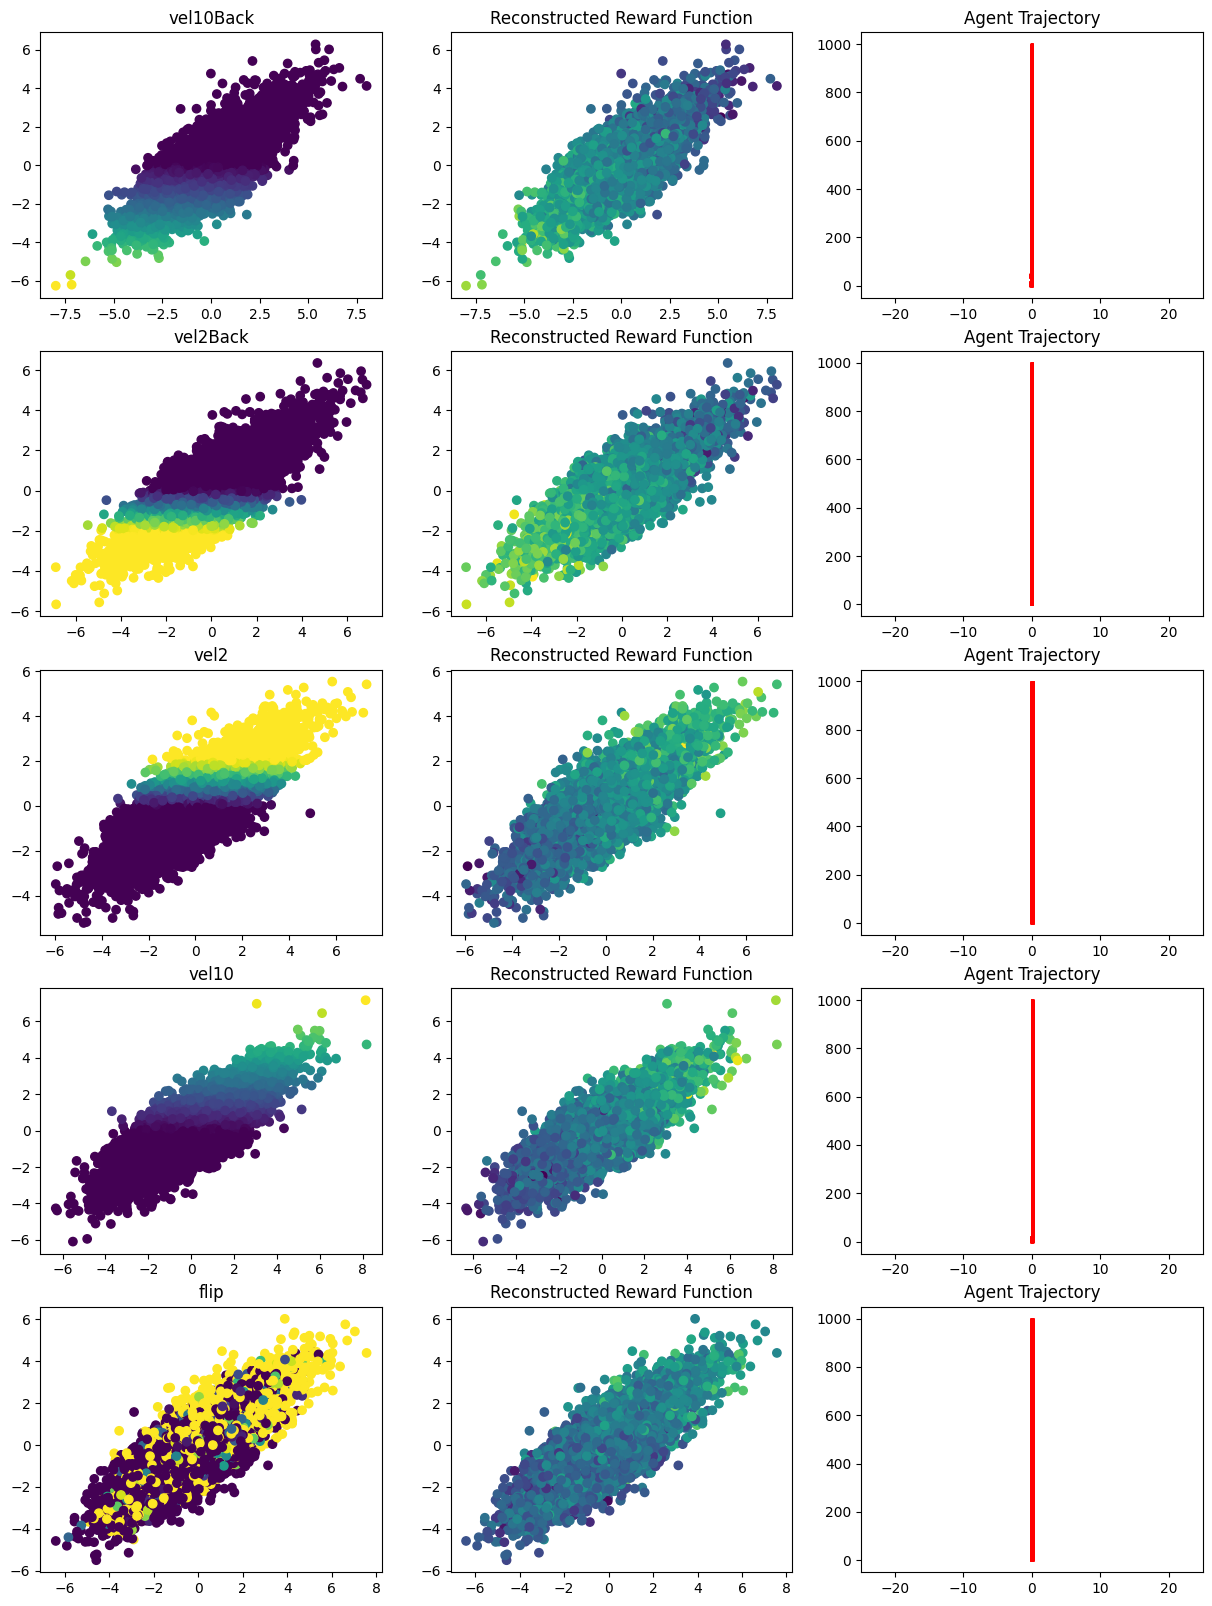

In [ ]:


for step in tqdm(range(200_000)):

    obs, action, next_obs, _ = get_iql_training_data(dataset, batch_size=1024)

    fb_agent.update(obs, action, next_obs, step=step)
    
    
    
    
    if step % 10 == 0:
    
        benchmark_rewards = run_benchmark(env, fb_agent, benchmarks, num_evals=5)
        
        rewards_logs = np.concatenate((rewards_logs, benchmark_rewards.reshape(-1, 1)), axis=-1)
        # print(rewards_logs)
        num_cols = 4
        num_rows = len(benchmarks)//num_cols + int(len(benchmarks) % num_cols != 0)
        fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*6, num_rows*5))
        axs = axs.flatten()
        
        for i in range(len(benchmarks)):
            _, benchmark_test_label, _ = benchmarks[i]
            axs[i].plot(rewards_logs[i])
            axs[i].set_title(benchmark_test_label)
    
        # plt.savefig(f"{args.LOGS_FOLDER}/rewards.png")
        # plt.close()
        
                    
        # torch.save(iql_agent.state_dict(), f"{args.MODEL_SAVE_FOLDER}/iql_agent.pth")
    
    break

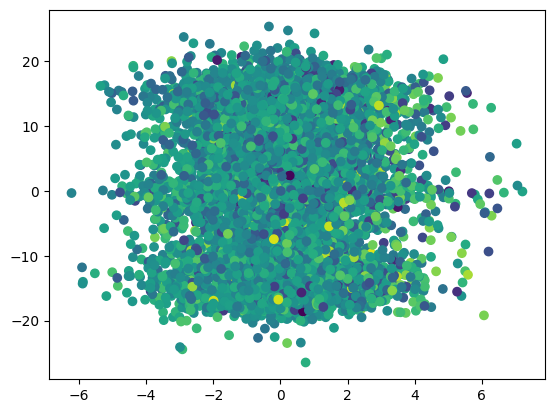

In [74]:
z = fb_agent.sample_z(1, device=device)

eval_states, _, _, eval_aux = get_iql_training_data(dataset, batch_size=10_000)

r = fb_agent.get_implicit_reward(eval_states, z)

plt.scatter(eval_states[..., 8].cpu(), eval_states[..., 16].cpu(), c=r.cpu())

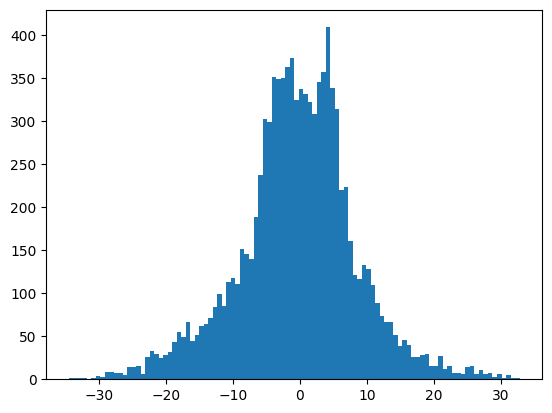

In [75]:
_ = plt.hist(r.cpu(), bins=100)

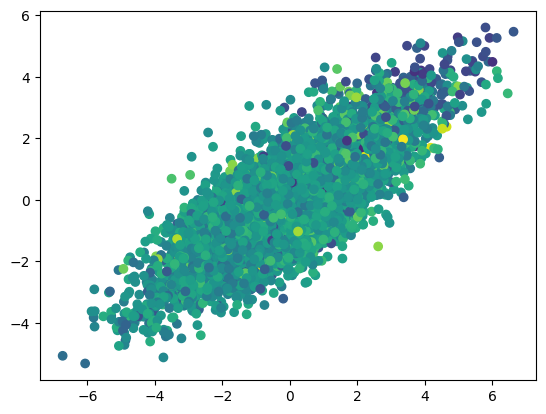